# Week 6 - Imagery Alignment: Introduction and Simple Examples

---

## 1. Introduction and Context

In remote sensing, aligning images from different sensors or different times is a critical step in many applications such as sea ice monitoring, land cover change, or multi-sensor data fusion. For instance, aligning a Sentinel-2 image to a Sentinel-3 image involves co-locating spatial points so that each pixel in one dataset corresponds to the same ground location (or sea/ice location) in the other dataset.

However, imagery alignment is often complicated by:
- Sensor differences (different resolutions, spectral bands, angles).  
- Scene dynamics (moving sea ice, vegetation changes, etc.).  
- Acquisition timing differences (the Earth or ice might move between acquisitions).

### 1.1 Four Methods for Image Alignment

1. **Auto-correlation (Cross-correlation)**  
   - A straightforward spatial-domain approach that searches for the shift (translation) maximizing the correlation between two images.  
   - Often implemented by brute-force correlation (rolling or shifting the image) or by using 2D convolution methods.

2. **Phase Correlation**  
   - A frequency-domain method leveraging the Fourier shift theorem.  
   - Typically faster for large images and can provide sub-pixel accuracy.  
   - Commonly used in remote sensing for global registration of two images that differ only by translation.

3. **ECC (Enhanced Correlation Coefficient)**  
   - An iterative, gradient-based approach (available in OpenCV’s `findTransformECC`) that maximizes a correlation measure between two images.  
   - Can be used for translation, affine, or homography alignment, but here we focus on translation mode.  
   - Often converges quickly and handles small or moderate shifts well.

4. **SEA-RAFT (Optical Flow–Based Estimation)**
   - A state-of-the-art deep learning approach that predicts dense pixel-wise motion (optical flow) between frames.
   - While computationally intensive and complex to train, it offers superior accuracy by leveraging pretrained weights from large-scale computer vision datasets.
   - For this work, we utilize the authors' pretrained models, though performance could be further optimised through fine-tuning specifically on satellite imagery.

In this Notebook, we will:
1. Introduce the basic concepts behind these three methods.  
2. Demonstrate them on simple, synthetic examples (e.g., 2D arrays or toy images).  
3. Lay groundwork for applying these methods to real satellite data in *Notebook 2*.



In this Notebook, we will:
1. Introduce the basic concepts behind these three methods.  
2. Demonstrate them on simple, synthetic examples (e.g., 2D arrays or toy images).  
3. Lay groundwork for applying these methods to real satellite data in *Notebook 2*.



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import correlate2d
import cv2

%matplotlib inline

ModuleNotFoundError: No module named 'ot'

## Create synthetic images for example

This cell what we do is to create a synthetic pair of original image and shifted image so we can use them to illustrate the performance of the algorithm.

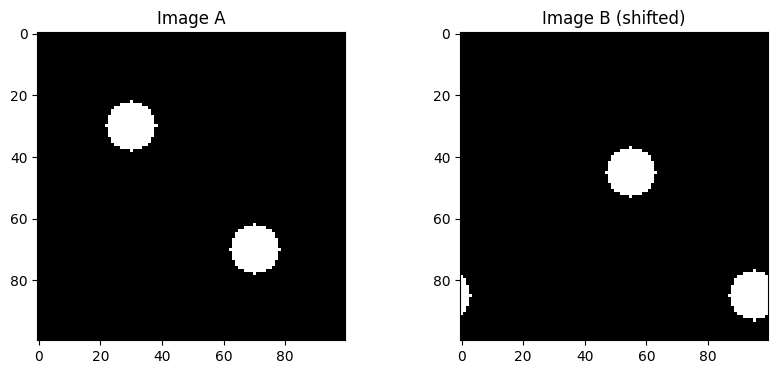

In [ ]:
def create_synthetic_image(size=(100, 100), centers=[(50, 50)], radius=10, intensity=1.0):
    """
    Create a synthetic image with circular bright spots.
    size: (height, width)
    centers: list of (row, col) circle centers
    radius: radius of circles
    intensity: pixel value inside the circle
    """
    img = np.zeros(size, dtype=np.float32)
    for c in centers:
        rr, cc = np.ogrid[:size[0], :size[1]]
        mask = (rr - c[0])**2 + (cc - c[1])**2 <= radius**2
        img[mask] = intensity
    return img

imageA = create_synthetic_image(
    size=(100, 100),
    centers=[(30, 30), (70, 70)],
    radius=8,
    intensity=1.0
)

#We can define a known shift, e.g., (dy, dx) = (5, 10)
known_shift = (15, 25)

def shift_image(img, shift):
    """
    Shift the image by (dy, dx) using np.roll for simplicity.
    This is a naive wrap-around shift, but it's enough to demonstrate the concept.
    """
    dy, dx = shift
    shifted = np.roll(img, dy, axis=0)
    shifted = np.roll(shifted, dx, axis=1)
    return shifted

imageB = shift_image(imageA, known_shift)

# We visualise them here
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(imageA, cmap='gray')
axes[0].set_title('Image A')
axes[1].imshow(imageB, cmap='gray')
axes[1].set_title('Image B (shifted)')
plt.show()


## Auto-correlation

Auto-correlation (or spatial cross-correlation) is a *direct* method to find the shift between two images by measuring how strongly one image correlates with various shifted versions of the other. Concretely, you can think of **“sliding”** one image over another in small increments and computing a correlation score at each step. The shift that maximizes this score is considered the best alignment.

- **Pros**: Easy to grasp conceptually, works well for moderate image sizes, and doesn’t require special libraries beyond basic 2D operations.
- **Cons**: Can be **slow** if you do a large brute-force search, and it only handles *pure translation* (no rotation or scaling).  



Known shift:        (26, 5)
Estimated shift (CC): (np.int64(26), np.int64(5))


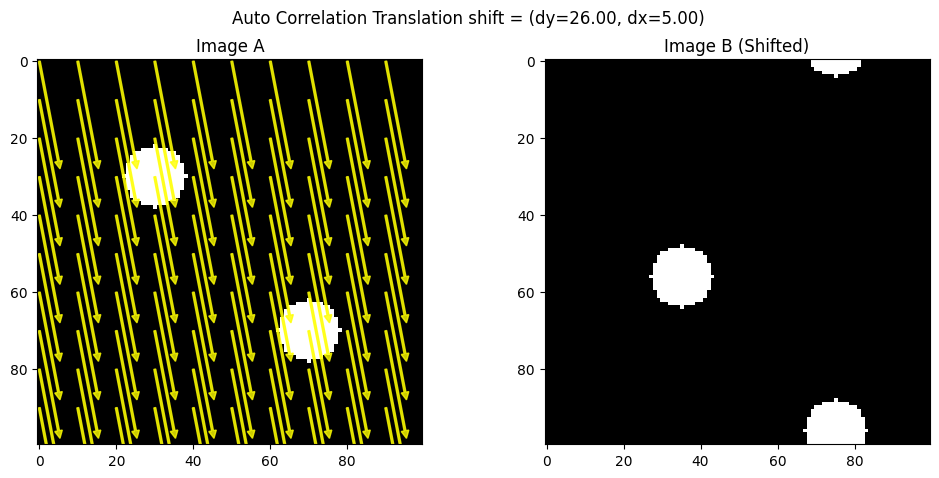

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow
from scipy.signal import correlate2d

def find_shift_via_cross_correlation(imgA, imgB):
    """
    Compute the shift between imgA and imgB via cross-correlation.
    BUT then negate the result to match the (dy, dx) we used in np.roll(imageA, (dy, dx)).

    Returns (dy, dx) in the same sign convention as the 'shift_image' function.
    """
    corr = correlate2d(imgA, imgB, boundary='fill', mode='full')
    max_idx = np.unravel_index(np.argmax(corr), corr.shape)

    # By default, this returns how to move B-->A. We'll call those (shift_y, shift_x).
    shift_y = max_idx[0] - imgA.shape[0] + 1
    shift_x = max_idx[1] - imgA.shape[1] + 1

    # Negate them to get A-->B
    return (-shift_y, -shift_x)

def visualize_shift_arrows(imgA, imgB, shift, step=10, method_name="ECC"):
    (dy, dx) = shift

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Image A with arrows
    axA.imshow(imgA, cmap='gray')
    axA.set_title("Image A")

    h, w = imgA.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)

    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, dx, dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    # Plot Image B without arrows
    axB.imshow(imgB, cmap='gray')
    axB.set_title("Image B (Shifted)")

    plt.suptitle(f"{method_name} shift = (dy={dy:.2f}, dx={dx:.2f})")
    plt.show()

def create_synthetic_image(size=(100, 100), centers=[(30, 30), (70, 70)], radius=8, intensity=1.0):
    img = np.zeros(size, dtype=np.float32)
    rr, cc = np.ogrid[:size[0], :size[1]]
    for c in centers:
        mask = (rr - c[0])**2 + (cc - c[1])**2 <= radius**2
        img[mask] = intensity
    return img

def shift_image(img, shift):
    (dy, dx) = shift
    shifted = np.roll(img, dy, axis=0)
    shifted = np.roll(shifted, dx, axis=1)
    return shifted

# Create two synthetic images
imageA = create_synthetic_image()
known_shift = (26, 5)
imageB = shift_image(imageA, known_shift)

# Estimate shift (now it should match known_shift)
estimated_shift_cc = find_shift_via_cross_correlation(imageA, imageB)
print("Known shift:       ", known_shift)
print("Estimated shift (CC):", estimated_shift_cc)

# Visualize with arrows on a sampled grid
visualize_shift_arrows(imageA, imageB, estimated_shift_cc, step=10, method_name="Auto Correlation Translation")


## Phase Correlation

Phase correlation moves the cross-correlation problem into the **frequency domain**. By taking the Fourier transform of each image, multiplying one by the complex conjugate of the other, and looking at the **peak** in the inverse transform, you recover the shift. This leverages the **Fourier shift theorem**, which says that a translation in the spatial domain shows up as a **linear phase difference** in the frequency domain.

- **Pros**: Faster than brute-force auto-correlation (especially for large images), naturally yields subpixel accuracy, and is robust to certain intensity variations.
- **Cons**: Requires computing the Fourier transform; can become tricky if the images have major differences other than translation (e.g., rotation, scale changes).  


Known shift: (15, 10)
Estimated shift (Phase Corr): (np.float32(15.0), np.float32(10.0))


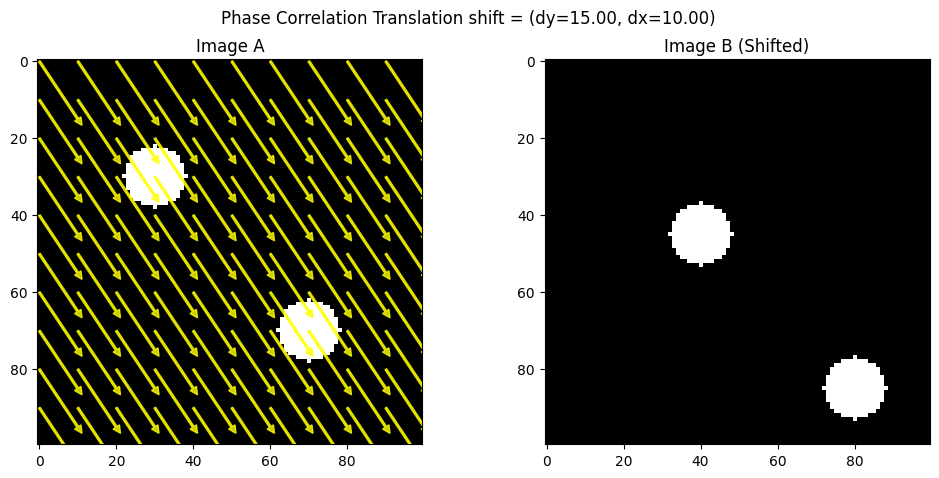

In [ ]:
!pip install scikit-image

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import fourier_shift
from skimage.registration import phase_cross_correlation
from matplotlib.patches import FancyArrow


def phase_corr_estimate_shift(imgA, imgB):
    """
    phase_cross_correlation(imgA, imgB) returns the shift that aligns B to A.
    If we want the shift that moves A to B (same sign as shift_image), we negate it.
    """
    shift, error, diffphase = phase_cross_correlation(imgA, imgB)
    # shift is (row_shift, col_shift) => let's rename (dyBtoA, dxBtoA)
    (dyBtoA, dxBtoA) = shift

    # We want the shift from A->B, so just negate:
    dyAtoB = -dyBtoA
    dxAtoB = -dxBtoA
    return (dyAtoB, dxAtoB)


def visualize_shift_arrows(imgA, imgB, shift, step=10, method_name="ECC"):
    (dy, dx) = shift

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Image A with arrows
    axA.imshow(imgA, cmap='gray')
    axA.set_title("Image A")

    h, w = imgA.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)

    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, dx, dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    # Plot Image B without arrows
    axB.imshow(imgB, cmap='gray')
    axB.set_title("Image B (Shifted)")

    plt.suptitle(f"{method_name} shift = (dy={dy:.2f}, dx={dx:.2f})")
    plt.show()


imageA = create_synthetic_image()

known_shift = (15, 10)

imageB = shift_image(imageA, known_shift)

estimated_shift_pc = phase_corr_estimate_shift(imageA, imageB)
print("Known shift:", known_shift)
print("Estimated shift (Phase Corr):", estimated_shift_pc)
visualize_shift_arrows(imageA, imageB, estimated_shift_pc, step=10, method_name="Phase Correlation Translation")



## ECC (Enhanced Correlation Coefficient) Alignment

## ECC (Enhanced Correlation Coefficient)

ECC is an *iterative* approach that tries to **maximize** a particular correlation measure between two images. It’s available in OpenCV’s `findTransformECC` function and can handle not only translation but also affine or homography transformations (if configured). For translation-only alignment, ECC updates the image transformation parameters step by step, converging to the shift that yields the highest correlation.

- **Pros**: Often more robust and *faster* than naive brute force; can yield subpixel accuracy; can be extended to more complex transformations if needed.
- **Cons**: Requires a decent initial guess for bigger shifts, and it’s more of a “black box” iterative method than a simple correlation map.  




Known shift: (5, 16)
Estimated shift (ECC): (np.float32(4.9955196), np.float32(15.99729)) CC: 0.999999672404866


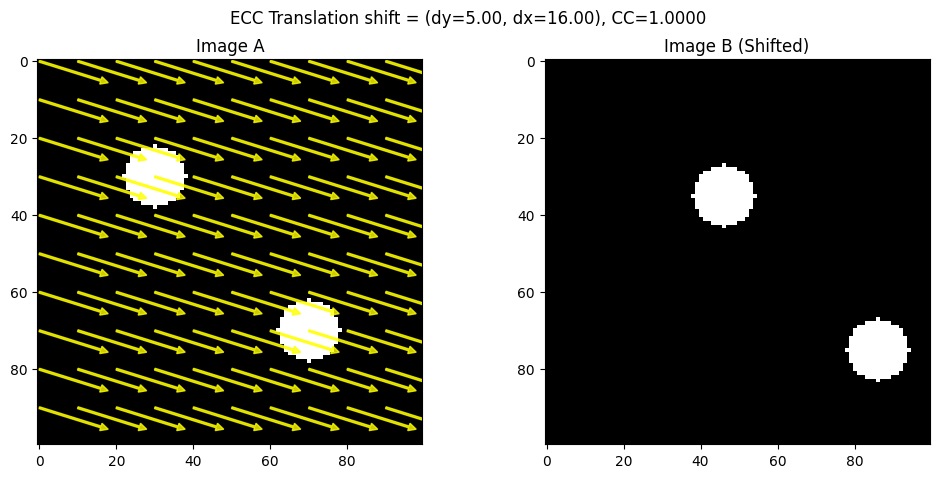

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

def align_ecc_translation(imgA, imgB, num_iterations=300, termination_eps=1e-6, gaussFiltSize=1):
    """
    Align imgB to imgA using ECC with a translation model.
    Handles large shifts by providing an initial guess.
    """
    imgA_f = imgA.astype(np.float32) / 255.0  # Normalize
    imgB_f = imgB.astype(np.float32) / 255.0  # Normalize

    warp_matrix = np.array([[1, 0, 10], [0, 1, 15]], dtype=np.float32)  # Initial guess for large shift

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, num_iterations, termination_eps)

    try:
        cc, warp_matrix = cv2.findTransformECC(
            templateImage=imgA_f,
            inputImage=imgB_f,
            warpMatrix=warp_matrix,
            motionType=cv2.MOTION_TRANSLATION,
            criteria=criteria
        )
        dx = warp_matrix[0, 2]
        dy = warp_matrix[1, 2]
        return (dy, dx), cc

    except cv2.error as e:
        print("ECC failed:", e)
        return (None, None), None  # Return None if ECC fails


def shift_image(img, shift):
    """
    Shift the image by (dy, dx) using np.roll.
    """
    dy, dx = shift
    shifted = np.roll(img, dy, axis=0)
    shifted = np.roll(shifted, dx, axis=1)
    return shifted


imageA = create_synthetic_image()
known_shift = (5, 16)

imageB = shift_image(imageA, known_shift)

ecc_shift, cc_value = align_ecc_translation(imageA, imageB)

print("Known shift:", known_shift)
print("Estimated shift (ECC):", ecc_shift, "CC:", cc_value)


def visualize_ecc_shift_arrows(imgA, imgB, shift, step=10, method_name="ECC"):
    (dy, dx) = shift

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

    # Plot Image A with arrows
    axA.imshow(imgA, cmap='gray')
    axA.set_title("Image A")

    h, w = imgA.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)

    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, dx, dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    # Plot Image B without arrows
    axB.imshow(imgB, cmap='gray')
    axB.set_title("Image B (Shifted)")

    plt.suptitle(f"{method_name} shift = (dy={dy:.2f}, dx={dx:.2f}), CC={cc_value:.4f}")
    plt.show()


# Example Usage
visualize_ecc_shift_arrows(imageA, imageB, ecc_shift, step=10, method_name="ECC Translation")



For ECC, we have also included an example on alignment on rotated images.

Known rotation: 30
Estimated shift and rotation (ECC): (np.float32(31.69622), np.float32(-18.302961), np.float32(-29.998287)) CC: 0.9998337715512696


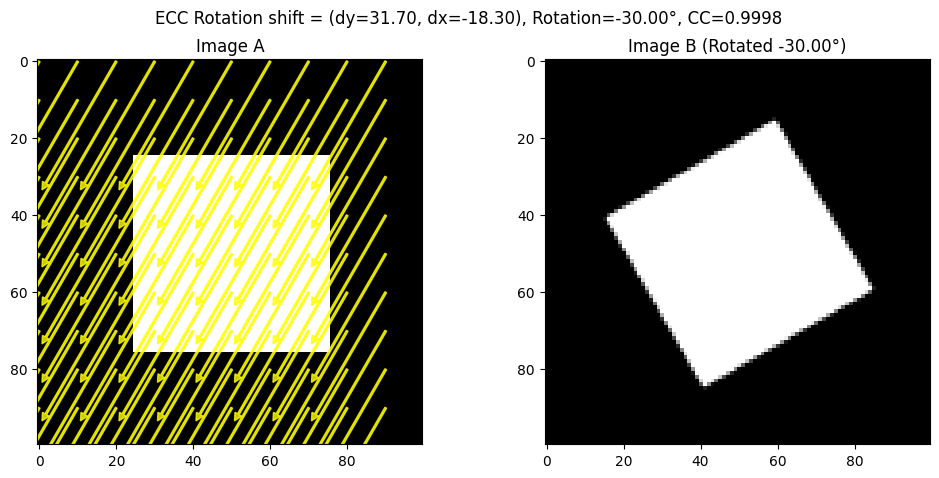

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow

def create_synthetic_image(size=(100, 100), shape="rectangle"):
    """
    Creates a synthetic image with a simple geometric shape.
    """
    img = np.zeros(size, dtype=np.uint8)
    h, w = img.shape

    if shape == "rectangle":
        cv2.rectangle(img, (w//4, h//4), (3*w//4, 3*h//4), 255, -1)
    elif shape == "circle":
        cv2.circle(img, (w//2, h//2), w//4, 255, -1)

    return img


def rotate_image(img, angle, center=None):
    """
    Rotate the image around its center.
    """
    h, w = img.shape
    if center is None:
        center = (w//2, h//2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, rotation_matrix, (w, h))
    return rotated


def align_ecc_rotation(imgA, imgB, num_iterations=300, termination_eps=1e-6):
    """
    Align imgB to imgA using ECC with an Euclidean transformation model (rotation + translation).
    """
    imgA_f = imgA.astype(np.float32) / 255.0
    imgB_f = imgB.astype(np.float32) / 255.0

    warp_matrix = np.eye(2, 3, dtype=np.float32)  # Identity matrix for Euclidean transform

    criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, num_iterations, termination_eps)

    try:
        cc, warp_matrix = cv2.findTransformECC(
            templateImage=imgA_f,
            inputImage=imgB_f,
            warpMatrix=warp_matrix,
            motionType=cv2.MOTION_EUCLIDEAN,
            criteria=criteria
        )

        dx = warp_matrix[0, 2]
        dy = warp_matrix[1, 2]
        theta = np.arctan2(warp_matrix[1, 0], warp_matrix[0, 0]) * (180.0 / np.pi)

        return (dy, dx, theta), cc

    except cv2.error as e:
        print("ECC failed:", e)
        return (None, None, None), None


# Create Synthetic Image and Rotate
imageA = create_synthetic_image()
known_rotation = 30  # Degrees
imageB = rotate_image(imageA, known_rotation)

# Apply ECC Rotation Alignment
ecc_shift, cc_value = align_ecc_rotation(imageA, imageB)

print("Known rotation:", known_rotation)
print("Estimated shift and rotation (ECC):", ecc_shift, "CC:", cc_value)


def visualize_ecc_rotation_arrows(imgA, imgB, shift, step=10, method_name="ECC"):
    (dy, dx, theta) = shift

    fig, (axA, axB) = plt.subplots(1, 2, figsize=(12, 5))

    axA.imshow(imgA, cmap='gray')
    axA.set_title("Image A")

    h, w = imgA.shape
    rows = np.arange(0, h, step)
    cols = np.arange(0, w, step)

    for r in rows:
        for c in cols:
            axA.add_patch(FancyArrow(c, r, dx, dy, color="yellow",
                                     width=0.5, head_width=2, head_length=2, alpha=0.8))

    axB.imshow(imgB, cmap='gray')
    axB.set_title(f"Image B (Rotated {theta:.2f}°)")

    plt.suptitle(f"{method_name} shift = (dy={dy:.2f}, dx={dx:.2f}), Rotation={theta:.2f}°, CC={cc_value:.4f}")
    plt.show()


# Visualize the Rotation Alignment
visualize_ecc_rotation_arrows(imageA, imageB, ecc_shift, step=10, method_name="ECC Rotation")

## SeaRAFT
Simple, Efficient, Accurate RAFT (SEARaft) is a modern AI-based optical-flow and image registration method. It is a refinement of the AI-based approach Recurrent All-Pairs Field Transforms (RAFT) tailored for estimating motion between frames.

https://arxiv.org/abs/2405.14793
https://arxiv.org/abs/2003.12039

SEARaft iteratively updates a dense motion field (optical flow) between image pairs using recurrent modules aim at improving alignment step by step. The following code is developed by François Chadebecq.

In [ ]:
# Install required deep learning, image processing, and visualization libraries
!pip install torch torchvision opencv-python matplotlib

# OS utilities (file system checks, paths)
import os
# System utilities (used to modify Python path)
import sys
# Deep learning framework
import torch
# Numerical computations
import numpy as np
# Computer vision library
import cv2
# Visualization
import matplotlib.pyplot as plt
# Image loading / manipulation
from PIL import Image

# Download SEA-RAFT if it is not already available
if not os.path.exists("SEA-RAFT"):
    !git clone https://github.com/princeton-vl/SEA-RAFT.git
else:
    print("SEA-RAFT folder exists — skipping clone")

# Simple container for configuration objects
from types import SimpleNamespace
# Allows Python to find RAFT modules inside the repository
sys.path.append("SEA-RAFT/core")
# Main RAFT model class
from raft import RAFT
# Utility for padding images to dimensions compatible with the network
from utils.utils import InputPadder

Cloning into 'SEA-RAFT'...
remote: Enumerating objects: 115, done.
remote: Counting objects: 100% (40/40), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 115 (delta 28), reused 22 (delta 22), pack-reused 75 (from 1)
Receiving objects: 100% (115/115), 8.16 MiB | 16.20 MiB/s, done.
Resolving deltas: 100% (51/51), done.


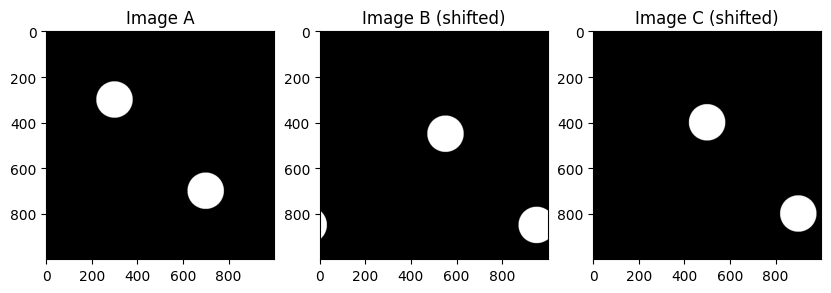

In [ ]:
def create_synthetic_image(size=(100, 100), centers=[(50, 50)], radius=10, intensity=1.0):
    """
    Create a synthetic image with circular bright spots.
    size: (height, width)
    centers: list of (row, col) circle centers
    radius: radius of circles
    intensity: pixel value inside the circle
    """
    img = np.zeros(size, dtype=np.float32)
    for c in centers:
        rr, cc = np.ogrid[:size[0], :size[1]]
        mask = (rr - c[0])**2 + (cc - c[1])**2 <= radius**2
        img[mask] = intensity
    return img

imageA = create_synthetic_image(
    size=(1000, 1000),
    centers=[(300, 300), (700, 700)],
    radius=80,
    intensity=1.0
)


def shift_image(img, shift):
    """
    Shift the image by (dy, dx) using np.roll for simplicity.
    This is a naive wrap-around shift, but it's enough to demonstrate the concept.
    """
    dy, dx = shift
    shifted = np.roll(img, dy, axis=0)
    shifted = np.roll(shifted, dx, axis=1)
    return shifted

#We can define a known shift, e.g., (dy, dx) = (150, 250)
known_shift = (150, 250)
imageB = shift_image(imageA, known_shift)
known_shift = (100, 200)
imageC = shift_image(imageA, known_shift)

# We visualise them here
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
axes[0].imshow(imageA, cmap='gray')
axes[0].set_title('Image A')
axes[1].imshow(imageB, cmap='gray')
axes[1].set_title('Image B (shifted)')
axes[2].imshow(imageC, cmap='gray')
axes[2].set_title('Image C (shifted)')
plt.show()


### Optical Flow–Based Displacement Estimation with SEA-RAFT
SEA-RAFT achieves state-of-the-art optical flow accuracy on standard benchmarks. However, it is computationally expensive, has relatively slow inference, and is complex to train.

In this work, we therefore rely on pretrained model weights provided by the authors of SEA-RAFT, which were trained on standard computer-vision image registration datasets (e.g., in-the-wild datasets). We note that a dedicated training or fine-tuning on satellite imagery would likely further improve performance for our application.

/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


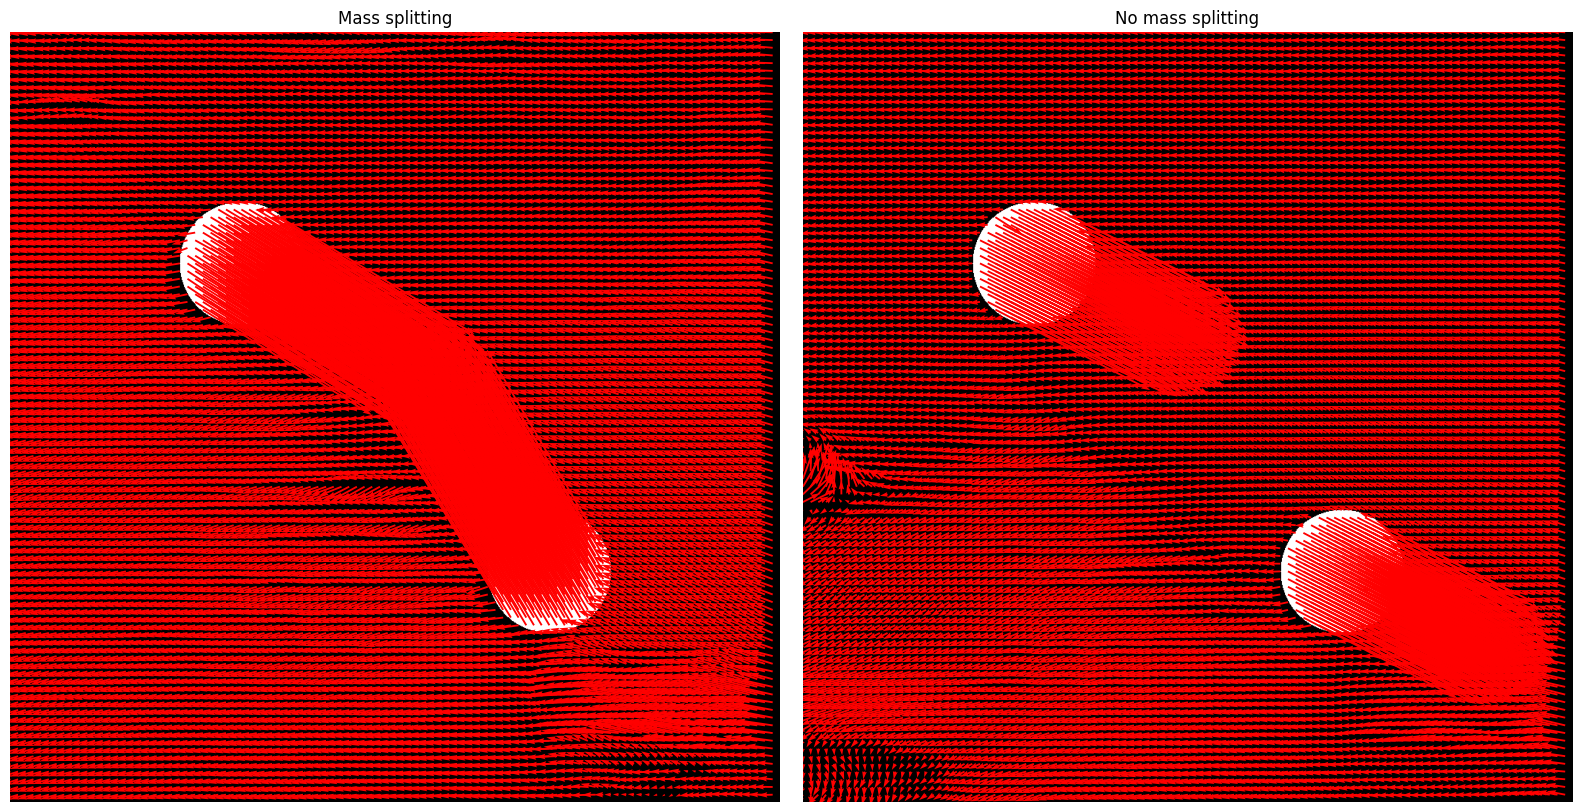

In [ ]:
def grayscale_to_rgb(img, normalize=True):
    """
    Convert a single-channel grayscale image to a 3-channel RGB image.

    SEA‑RAFT expects RGB images as input.

    This function converts a grayscale image
    to RGB by replicating the grayscale channel across the three RGB channels.

    Parameters
    ----------
    img : np.ndarray
        Input grayscale image of shape (H, W).
    normalize : bool, optional (default=True)
        If True, the image will be normalized to the [0, 255] range.
        For real data, additional preprocessing (e.g., contrast enhancement)
        may be required.

    Returns
    -------
    rgb_img : np.ndarray
        RGB image of shape (H, W, 3), dtype=np.uint8.
    """
    if img.ndim != 2:
        raise ValueError("Input image must be single-channel (H, W)")

    img_out = img.copy()

    if normalize:
        img_min, img_max = img_out.min(), img_out.max()
        if img_max > img_min:
            img_out = (img_out - img_min) / (img_max - img_min)
        img_out = (img_out * 255).astype(np.uint8)
    else:
        img_out = img_out.astype(np.uint8)

    # Stack into 3 identical channels
    rgb_img = np.stack([img_out, img_out, img_out], axis=-1)

    return rgb_img

def sea_raft_flow(img1, img2, model_path=None, device='cpu'):
    """
    Estimate dense optical flow (displacement field) between two RGB images using SEA‑RAFT.

    Parameters
    ----------
    img1 : np.ndarray
        Source RGB image of shape (H, W, 3), dtype=np.uint8 or float.
    img2 : np.ndarray
        Target RGB image of shape (H, W, 3), dtype=np.uint8 or float.
    model_path : str, optional
        Path to pre-trained SEA‑RAFT weights. If None, defaults to the standard model path.
    device : str, optional
        Device to run the model on ('cpu' or 'cuda').

    Returns
    -------
    u_disp : np.ndarray
        Horizontal displacement (dx) for each pixel, shape (H, W).
    v_disp : np.ndarray
        Vertical displacement (dy) for each pixel, shape (H, W).
    """

    # Default dictionary storing standard SEARaft parameters/arguments
    args_dict = {
        "name": "spring-M",
        "dataset": "spring",
        "gpus": [0,1,2,3,4,5,6,7],
        "use_var": True,
        "var_min": 0,
        "var_max": 10,
        "pretrain": "resnet34",
        "initial_dim": 64,
        "block_dims": [64,128,256],
        "radius": 4,
        "dim": 128,
        "num_blocks": 2,
        "iters": 4,
        "image_size": [540,960],
        "scale": -1,
        "batch_size": 32,
        "epsilon": 1e-08,
        "lr": 0.0004,
        "wdecay": 1e-05,
        "dropout": 0,
        "clip": 1.0,
        "gamma": 0.85,
        "num_steps": 120000,
        "restore_ckpt": None,
        "coarse_config": None,
        "cfg": "SEA-RAFT/config/eval/spring-M.json",
        "path": "/content/drive/MyDrive/PhD Year 3/GEOL0069_test_2026/Week 6/Tartan-C-T-TSKH-spring540x960-M.pth",
        "url": None,
        "device": device
    }

    # Convert the dictionary to an arg namespace (compatibility)
    args = SimpleNamespace(**args_dict)

    # Instantiate the RAFT model
    model = RAFT(args)
    model_path = args.path
    if model_path:
        model.load_state_dict(torch.load(model_path,map_location=torch.device(device)))
    model.to(device)
    model.eval()

    # Convert input images to tensors
    img1_t = torch.from_numpy(img1).permute(2,0,1).float()[None].to(device)
    img2_t = torch.from_numpy(img2).permute(2,0,1).float()[None].to(device)

    # Pad to multiple of 8 (constraint related to the architecture design)
    padder = InputPadder(img1_t.shape)
    img1_t, img2_t = padder.pad(img1_t, img2_t)

    # Evaluation
    with torch.no_grad():
        outputs = model(img1_t, img2_t, iters=20, test_mode=True)
        flow = outputs['flow'][-1]  # last iteration

    # Extract the horizontal and vertical flow (displacement) dx, dy
    flow = flow.squeeze(0)         # remove batch -> shape (2, H, W)
    flow = flow.permute(1,2,0)     # (H, W, 2)

    u_disp = flow[...,0].cpu().numpy()  # horizontal
    v_disp = flow[...,1].cpu().numpy()  # vertical

    return u_disp, v_disp

# If needed: Helper function to plot the optical flow (displacement vectors)
def plot_quiver(img, dx, dy, skip=10, title="Displacement Field"):
    """
    Overlay a quiver plot (arrows) showing pixel-wise displacement vectors on top of an image.

    Parameters
    ----------
    img : np.ndarray
        Background image to display, typically RGB.
    dx : np.ndarray
        Horizontal displacement (flow) for each pixel.
    dy : np.ndarray
        Vertical displacement (flow) for each pixel.
    skip : int, optional (default=10)
        Only every `skip`-th pixel in both x and y directions will be plotted.
    title : str, optional
        Title of the plot.

    Notes
    -----
    - The displacement vectors are drawn in red by default.
    - The quiver arrows are scaled to correspond to pixel displacements (scale=1).
    """
    h, w = dx.shape
    Y, X = np.mgrid[0:h, 0:w]
    plt.figure(figsize=(8,8))
    plt.imshow(img)
    plt.quiver(
        X[::skip, ::skip], Y[::skip, ::skip],
        dx[::skip, ::skip], dy[::skip, ::skip],
        angles='xy', scale_units='xy', scale=1 , color='red'
    )
    plt.title(title)
    plt.axis('off')
    plt.show()

# "Convert" images to RGB
imageA = grayscale_to_rgb(imageA)
imageB = grayscale_to_rgb(imageB)
imageC = grayscale_to_rgb(imageC)

# Estimate optical flow using SEARaft
dx_raft_AB, dy_raft_AB = sea_raft_flow(imageA, imageB, model_path=None)
dx_raft_AC, dy_raft_AC = sea_raft_flow(imageA, imageC, model_path=None)

# Display
skip = 10
fig, axes = plt.subplots(1, 2, figsize=(16,8))
h1, w1 = dx_raft_AB.shape
Y1, X1 = np.mgrid[0:h1, 0:w1]
axes[0].imshow(imageA)
axes[0].quiver(X1[::skip, ::skip], Y1[::skip, ::skip],
        dx_raft_AB[::skip, ::skip], dy_raft_AB[::skip, ::skip],
        angles='xy', scale_units='xy', scale=1, color='red'
    )
axes[0].set_title("Mass splitting")
axes[0].axis('off')

h2, w2 = dx_raft_AC.shape
Y2, X2 = np.mgrid[0:h2, 0:w2]
axes[1].imshow(imageA)
axes[1].quiver(
        X2[::skip, ::skip], Y2[::skip, ::skip],
        dx_raft_AC[::skip, ::skip], dy_raft_AC[::skip, ::skip],
        angles='xy', scale_units='xy', scale=1, color='red'
    )
axes[1].set_title("No mass splitting")
axes[1].axis('off')
plt.tight_layout()
plt.show()


### SEA-RAFT Performance on Rotational Motion

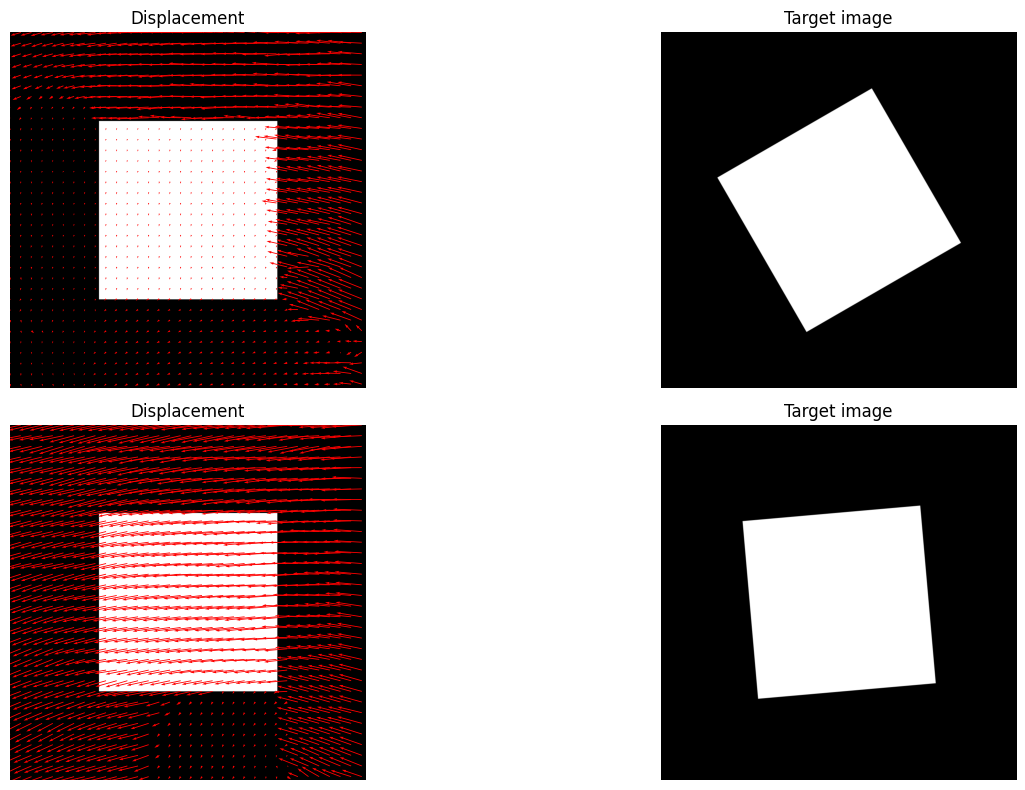

In [ ]:
def create_another_synthetic_image(size=(1000, 1000), shape="rectangle"):
    """
    Creates a synthetic image with a simple geometric shape.
    """
    img = np.zeros(size, dtype=np.uint8)
    h, w = img.shape

    if shape == "rectangle":
        cv2.rectangle(img, (w//4, h//4), (3*w//4, 3*h//4), 255, -1)
    elif shape == "circle":
        cv2.circle(img, (w//2, h//2), w//4, 255, -1)

    return img


def rotate_image(img, angle, center=None):
    """
    Rotate the image around its center.
    """
    h, w = img.shape
    if center is None:
        center = (w//2, h//2)

    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(img, rotation_matrix, (w, h))
    return rotated

# Create synthetic image and rotate it
imageA = create_another_synthetic_image()

known_rotation = 30  # Degrees
imageB = rotate_image(imageA, known_rotation)
known_rotation = 5  # Degrees
imageC = rotate_image(imageA, known_rotation)


#  "Convert" images to RGB
imageA = grayscale_to_rgb(imageA)
imageB = grayscale_to_rgb(imageB)
imageC = grayscale_to_rgb(imageC)

# Estimate optical flow using SEARaft
dx_raft_AB, dy_raft_AB = sea_raft_flow(imageA, imageB, model_path=None)
dx_raft_AC, dy_raft_AC = sea_raft_flow(imageA, imageC, model_path=None)

# Display
skip=30
fig, axes = plt.subplots(2, 2, figsize=(16,8))
h1, w1 = dx_raft_AB.shape
Y1, X1 = np.mgrid[0:h1, 0:w1]
axes[0,0].imshow(imageA)
axes[0,0].quiver(X1[::skip, ::skip], Y1[::skip, ::skip],
        dx_raft_AB[::skip, ::skip], dy_raft_AB[::skip, ::skip],
        angles='xy', scale_units='xy', scale=1, color='red'
    )
axes[0,0].set_title("Displacement")
axes[0,0].axis('off')
#######
h2, w2 = dx_raft_AB.shape
Y2, X2 = np.mgrid[0:h2, 0:w2]
axes[0,1].imshow(imageB)
axes[0,1].set_title("Target image")
axes[0,1].axis('off')
#######
h2, w2 = dx_raft_AC.shape
Y2, X2 = np.mgrid[0:h2, 0:w2]
axes[1,0].imshow(imageA)
axes[1,0].quiver(
       X2[::skip, ::skip], Y2[::skip, ::skip],
       dx_raft_AC[::skip, ::skip], dy_raft_AC[::skip, ::skip],
       angles='xy', scale_units='xy', scale=1, color='red'
      )
axes[1,0].set_title("Displacement")
axes[1,0].axis('off')
#######
h2, w2 = dx_raft_AC.shape
Y2, X2 = np.mgrid[0:h2, 0:w2]
axes[1,1].imshow(imageC)
axes[1,1].set_title("Target image")
axes[1,1].axis('off')

plt.tight_layout()
plt.show()